# Register a whole mouse brain streamed from S3 and resample it out of core

This notebook registers two whole mouse brains published as OME-Zarr in a
public S3 bucket, and resamples one onto the grid of the other at full
resolution without ever downloading a full-resolution volume:

1. `from_ome_zarr` opens both stores anonymously over S3; the arrays are lazy.
2. [ITKElastix](https://github.com/InsightSoftwareConsortium/ITKElastix)
   registers the coarsest level of the pyramids, which is small enough to fetch
   in a few seconds. The transform lives in physical space, so it applies at
   any level.
3. `resample` applies the transform at a fine level. For every
   output block it asks `resample_bounding_box` which region of
   the moving image is needed, reads only the S3 chunks inside it, and
   resamples through `itkwasm-downsample`. The blocks are tasks of one Dask
   graph that reference the moving chunks directly, so a chunk that several
   blocks need crosses the network once.
4. `to_ome_zarr` writes the lazy result to a local OME-Zarr block by block, so
   neither the input nor the output has to fit in memory.

The last section benchmarks the resample level by level, from local disk and
from S3.

The data are expansion-assisted selective plane illumination microscopy
(ExaSPIM) volumes from the Allen Institute for Neural Dynamics, in the
`aind-open-data` bucket. Each brain is a four-level pyramid: level 0 is
1776 × 1331 × 513 voxels at 30 × 30 × 40 µm (1.2 billion voxels, 2.4 GB of
`uint16`), level 3 is 2.4 million voxels. The two brains were chosen because
they share an acquisition orientation; other specimens in the cohort are
mirrored along X or Z and would need a flip before a rigid registration can
succeed.

Requirements beyond ngff-zarr: `pip install "ngff-zarr[remote]" itk-elastix matplotlib`.
The 2D companion example that builds the block-wise resample by hand is
[ITKElastix example 23](https://github.com/InsightSoftwareConsortium/ITKElastix/blob/main/examples/ITK_Example23_NgffZarrMultiscaleRegistration.ipynb).

In [1]:
import logging
import threading
import time
import warnings
from dataclasses import replace

import dask
import itk
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import psutil
from dask import threaded
from ngff_zarr import (
    NgffImage,
    from_ome_zarr,
    ngff_image_to_itk_image,
    resample,
    resample_bounding_box,
    to_multiscales,
    to_ngff_image,
    to_ome_zarr,
)

%matplotlib inline

# The AIND stores carry a "discrete" axis field that is not in OME-Zarr 0.4 and
# empty codec filter lists in their zarr 2 metadata. Both are reported on every
# open and change nothing here, so keep them out of the outputs.
logging.getLogger("ngff_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="Found an empty list of filters")

## Open the pyramids over S3

The bucket is public, so `storage_options={"anon": True}` reads it without AWS
credentials. Nothing is fetched here beyond the metadata.

Each block in flight holds its own moving-image crop, an itkwasm instance and
the output block it produces, about 62 MB for a 128³ block and 100 MB for a
192³ one, and the graph holds on top of that the moving chunks neighbouring
blocks share. The number of concurrent blocks, not the image size, is what the
peak follows: sixteen keeps an S3 link busy and stays around 4 GB at full
resolution. The benchmark at the end sweeps both knobs.


In [2]:
AIND = "s3://aind-open-data"
FIXED_URI = (
    f"{AIND}/exaSPIM_773889_2026-04-10_15-04-57_processed_2026-07-08_23-41-18"
    "/fusion2halves/SPIM.ome.zarr"
)
MOVING_URI = (
    f"{AIND}/exaSPIM_822174_2026-04-28_12-29-55_processed_2026-07-09_03-49-09"
    "/fusion2halves/SPIM.ome.zarr"
)

dask.config.set(scheduler="threads", num_workers=16)

storage_options = {"anon": True}
fixed_multiscales = from_ome_zarr(FIXED_URI, storage_options=storage_options)
moving_multiscales = from_ome_zarr(MOVING_URI, storage_options=storage_options)


def spatial(image: NgffImage) -> NgffImage:
    "Drop the singleton t and c axes: registration works on the 3D z, y, x volume."
    keep = [dim for dim in image.dims if dim in ("z", "y", "x")]
    index = tuple(slice(None) if dim in keep else 0 for dim in image.dims)
    return NgffImage(
        data=image.data[index],
        dims=keep,
        scale={dim: image.scale[dim] for dim in keep},
        translation={dim: image.translation[dim] for dim in keep},
        name=image.name,
        axes_units={dim: image.axes_units[dim] for dim in keep}
        if image.axes_units
        else None,
        axes_orientations=(
            {
                dim: image.axes_orientations[dim]
                for dim in keep
                if dim in image.axes_orientations
            }
            if image.axes_orientations
            else None
        ),
    )


fixed_levels = [spatial(image) for image in fixed_multiscales.images]
moving_levels = [spatial(image) for image in moving_multiscales.images]

print(
    f"{'level':>5} {'shape (z, y, x)':>20} {'voxels':>10} {'chunks':>18}  spacing (µm)"
)
for level, image in enumerate(fixed_levels):
    print(
        f"{level:>5} {image.data.shape!s:>20} {image.data.size / 1e6:>8.1f} M"
        f" {image.data.chunksize!s:>18}  {image.scale}"
    )

level      shape (z, y, x)     voxels             chunks  spacing (µm)
    0    (513, 1331, 1776)   1212.7 M    (256, 256, 256)  {'z': 40.0, 'y': 30.08, 'x': 30.08}
    1      (256, 665, 888)    151.2 M    (256, 256, 256)  {'z': 80.0, 'y': 60.16, 'x': 60.16}
    2      (128, 332, 444)     18.9 M    (128, 256, 256)  {'z': 160.0, 'y': 120.32, 'x': 120.32}
    3       (64, 166, 222)      2.4 M     (64, 166, 222)  {'z': 320.0, 'y': 240.64, 'x': 240.64}


## Register at the coarsest level

Level 3 of each brain is 64 × 166 × 222 voxels at 320 × 240 × 240 µm.
`ngff_image_to_itk_image` fetches it from S3 and hands Elastix a native
`itk.Image`; a rigid + affine registration takes a couple of seconds. The
transform lives in physical space (micrometers), so it applies unchanged to
the finer levels, whose grids differ from level 3 in spacing *and* origin
(these stores use a centre-of-voxel convention, so each level's translation
shifts by half the spacing change).

In [3]:
COARSE = 3

fixed_coarse = ngff_image_to_itk_image(fixed_levels[COARSE], wasm=False).astype(itk.F)
moving_coarse = ngff_image_to_itk_image(moving_levels[COARSE], wasm=False).astype(itk.F)

parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterMap(itk.ParameterObject.GetDefaultParameterMap("rigid"))
parameter_object.AddParameterMap(itk.ParameterObject.GetDefaultParameterMap("affine"))

start = time.perf_counter()
registration = itk.ElastixRegistrationMethod[
    type(fixed_coarse), type(moving_coarse)
].New(
    fixed_image=fixed_coarse,
    moving_image=moving_coarse,
    parameter_object=parameter_object,
)
registration.SetLogToConsole(False)
registration.Update()
print(f"Registration at level {COARSE}: {time.perf_counter() - start:.1f} s")

# ConvertToItkTransform hands back the itk.Transform base; the cast exposes the
# composite interface. The transform maps fixed points into moving space.
brain_transform = itk.CompositeTransform[itk.D, 3].cast(
    registration.ConvertToItkTransform(registration.GetCombinationTransform())
)

Registration at level 3: 0.9 s


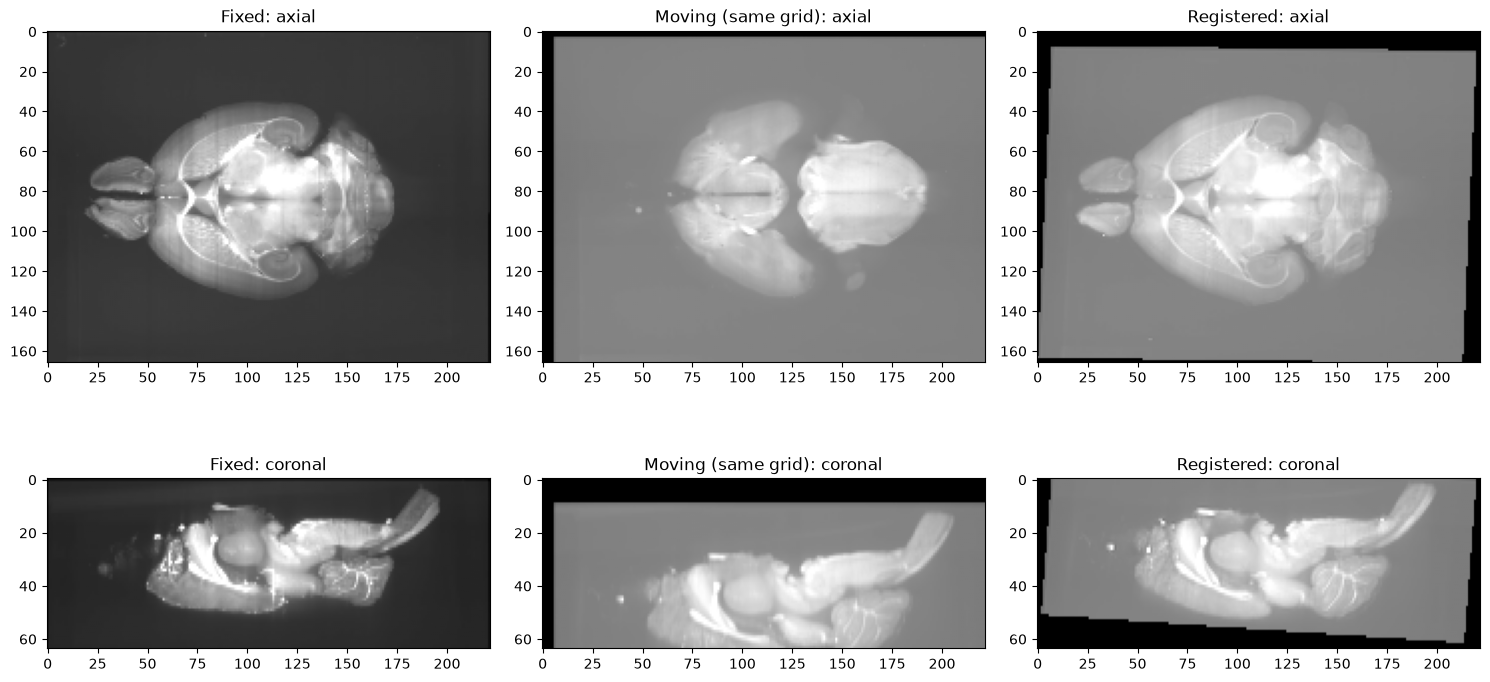

In [4]:
fixed_coarse_array = itk.array_from_image(fixed_coarse)
moving_on_fixed = itk.array_from_image(
    itk.resample_image_filter(
        moving_coarse, use_reference_image=True, reference_image=fixed_coarse
    )
)
registered_coarse = itk.array_from_image(registration.GetOutput())

fig, axs = plt.subplots(2, 3, figsize=[15, 8])
for column, (title, volume) in enumerate(
    [
        ("Fixed", fixed_coarse_array),
        ("Moving (same grid)", moving_on_fixed),
        ("Registered", registered_coarse),
    ]
):
    vmax = np.percentile(volume, 99.5)
    axs[0, column].imshow(volume[volume.shape[0] // 2], cmap="gray", vmax=vmax)
    axs[0, column].set_title(f"{title}: axial")
    axs[1, column].imshow(
        volume[:, volume.shape[1] // 2, :], cmap="gray", vmax=vmax, aspect=320 / 240.64
    )
    axs[1, column].set_title(f"{title}: coronal")
plt.tight_layout()
plt.show()

## Resample a fine level, streaming from S3 to a local OME-Zarr

`resample` returns a lazy `NgffImage` on the fixed grid; nothing
has been read yet. `to_ome_zarr` then drives the computation: each output block
reads the S3 chunks inside its own moving-image bounding box, resamples them,
and is written to disk as soon as it is done, with sixteen blocks in flight at
a time.

The block size is `fixed.data.chunks`, and it is also the chunking written to
the store, so it is worth choosing rather than inheriting: these stores carry
256³, and rechunking the fixed level to 128³ writes the chunking a 3D pyramid
usually wants and resamples faster, as the benchmark at the end shows.

`FINE` selects the level. Level 2 keeps the cell to a few seconds once its
chunks are downloaded; level 1 takes a couple of minutes on a typical
connection, and level 0 runs through the same code and is what the benchmark
below reports.


In [5]:
FINE = 2

resampled_brain = resample(brain_transform, fixed_levels[FINE], moving_levels[FINE])
print(
    f"Output grid: shape={resampled_brain.data.shape}, blocks={resampled_brain.data.npartitions}"
)

output_store = f"registered_822174_on_773889_level{FINE}.ome.zarr"
start = time.perf_counter()
to_ome_zarr(
    output_store, to_multiscales(resampled_brain, scale_factors=[]), overwrite=True
)
elapsed = time.perf_counter() - start
print(
    f"Wrote {output_store} in {elapsed:.0f} s "
    f"({resampled_brain.data.size / elapsed / 1e6:.2f} Mvoxel/s end to end)"
)

Output grid: shape=(128, 332, 444), blocks=4


Wrote registered_822174_on_773889_level2.ome.zarr in 15 s (1.27 Mvoxel/s end to end)


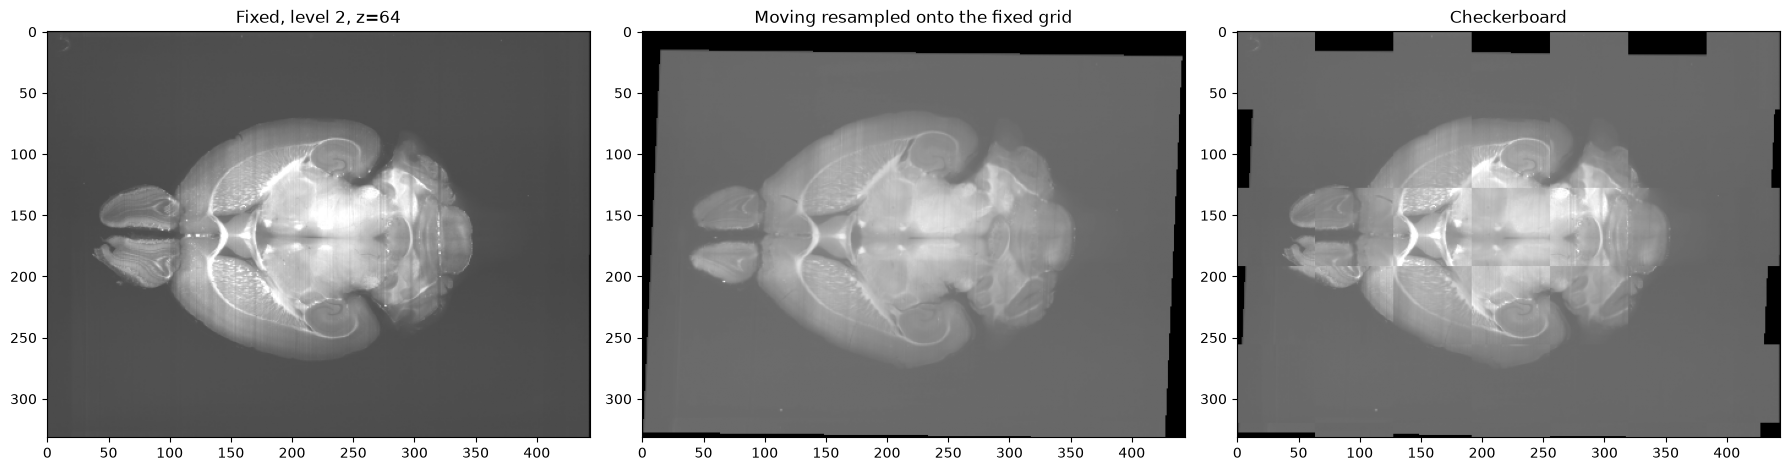

In [6]:
# Read the result back from disk and compare with the fixed brain on the same grid.
registered_brain = from_ome_zarr(output_store).images[0]
z = registered_brain.data.shape[0] // 2
registered_slice = np.asarray(registered_brain.data[z])
fixed_slice = np.asarray(fixed_levels[FINE].data[z])

# Checkerboard: alternating 64-pixel tiles of the fixed and registered slices.
tiles = (np.indices(fixed_slice.shape) // 64).sum(axis=0) % 2 == 0
checkerboard = np.where(tiles, fixed_slice, registered_slice)

fig, axs = plt.subplots(1, 3, figsize=[18, 5])
vmax = np.percentile(fixed_slice, 99.5)
axs[0].imshow(fixed_slice, cmap="gray", vmax=vmax)
axs[0].set_title(f"Fixed, level {FINE}, z={z}")
axs[1].imshow(registered_slice, cmap="gray", vmax=vmax)
axs[1].set_title("Moving resampled onto the fixed grid")
axs[2].imshow(checkerboard, cmap="gray", vmax=vmax)
axs[2].set_title("Checkerboard")
plt.tight_layout()
plt.show()

## The regions behind the blocks

Each output block reads its own region of the moving image, and
`resample_bounding_box` computes that region for any sub-grid of
the fixed image from geometry alone. The views below use level 2 with 64³
output blocks and one axial slice through the middle of the fixed brain; every
block whose z-range contains that slice is drawn on it, and the moving-image
region its resample reads is drawn on the corresponding moving slice. The
rectangles are the y-x footprints of 3D boxes.

1. one fixed block and the moving-image region its resample reads;
2. the same block with different `padding` values, the region grows to cover
   wider interpolation kernels;
3. every block of the slab, with its moving-image region in the same color.

In [7]:
VIEW = 2
BLOCK = 64
fixed_view, moving_view = fixed_levels[VIEW], moving_levels[VIEW]
view_grid = fixed_view.data.rechunk((BLOCK, BLOCK, BLOCK))
z_fixed = fixed_view.data.shape[0] // 2


def block_locations(array):
    "((z_start, z_stop), (y_start, y_stop), (x_start, x_stop)) for every block of the array."
    offsets = [np.concatenate([[0], np.cumsum(sizes)]) for sizes in array.chunks]
    return [
        tuple(
            (int(offsets[axis][i]), int(offsets[axis][i + 1]))
            for axis, i in enumerate(index)
        )
        for index in np.ndindex(*array.numblocks)
    ]


def block_bounding_box(location, padding=1):
    "The moving-image region one output block's resample reads. No pixels are read."
    shape = tuple(stop - start for start, stop in location)
    translation = {
        dim: fixed_view.translation[dim] + location[axis][0] * fixed_view.scale[dim]
        for axis, dim in enumerate(fixed_view.dims)
    }
    block_grid = to_ngff_image(
        np.zeros(shape, dtype=np.uint8),
        dims=fixed_view.dims,
        scale=fixed_view.scale,
        translation=translation,
    )
    return resample_bounding_box(
        brain_transform, block_grid, moving_view, padding=padding
    )


def draw_box(ax, start, size, color, label=None, linewidth=2):
    "Outline the y-x footprint of a region given per-dimension start/size in index space."
    ax.add_patch(
        mpatches.Rectangle(
            (start["x"] - 0.5, start["y"] - 0.5),
            size["x"],
            size["y"],
            edgecolor=color,
            facecolor="none",
            linewidth=linewidth,
            label=label,
        )
    )


slab = [
    location
    for location in block_locations(view_grid)
    if location[0][0] <= z_fixed < location[0][1]
]
# The block that contains the centre of the fixed brain.
centre = (z_fixed, fixed_view.data.shape[1] // 2, fixed_view.data.shape[2] // 2)
location = next(
    block
    for block in slab
    if all(start <= c < stop for (start, stop), c in zip(block, centre))
)
region = block_bounding_box(location)
# The moving slice to show: the middle of the region a one-voxel-thick slab of
# the fixed grid at z_fixed reads. The transform is not axis-aligned, so that
# region spans several moving slices.
_, ny, nx = fixed_view.data.shape
slice_region = block_bounding_box(((z_fixed, z_fixed + 1), (0, ny), (0, nx)))
z_moving = min(
    max(slice_region.start_index["z"] + slice_region.size["z"] // 2, 0),
    moving_view.data.shape[0] - 1,
)

fixed_view_slice = np.asarray(fixed_view.data[z_fixed])
moving_view_slice = np.asarray(moving_view.data[z_moving])
vmax_fixed = np.percentile(fixed_view_slice, 99.5)
vmax_moving = np.percentile(moving_view_slice, 99.5)
print(
    f"{len(slab)} blocks of {BLOCK}^3 cross the fixed slice z={z_fixed}; showing moving slice z={z_moving}"
)

42 blocks of 64^3 cross the fixed slice z=64; showing moving slice z=77


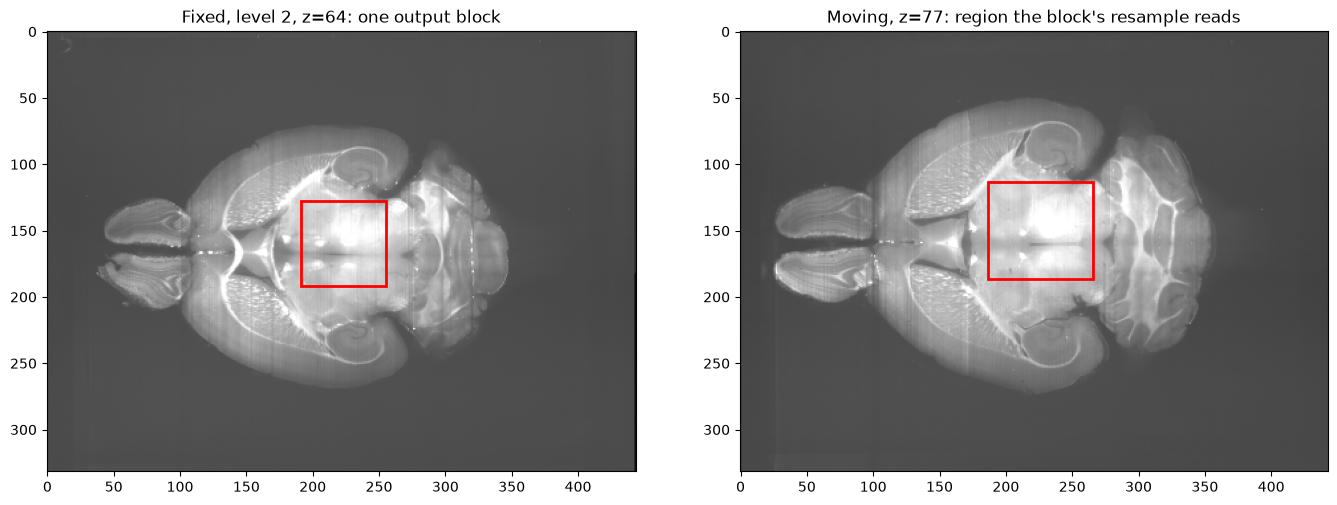

In [8]:
# 1. One fixed block and the moving-image region its resample reads.
fig, axs = plt.subplots(1, 2, figsize=[14, 5])
axs[0].imshow(fixed_view_slice, cmap="gray", vmax=vmax_fixed)
draw_box(
    axs[0],
    {"y": location[1][0], "x": location[2][0]},
    {"y": location[1][1] - location[1][0], "x": location[2][1] - location[2][0]},
    "red",
)
axs[0].set_title(f"Fixed, level {VIEW}, z={z_fixed}: one output block")
axs[1].imshow(moving_view_slice, cmap="gray", vmax=vmax_moving)
draw_box(axs[1], region.start_index, region.size, "red")
axs[1].set_title(f"Moving, z={z_moving}: region the block's resample reads")
plt.tight_layout()
plt.show()

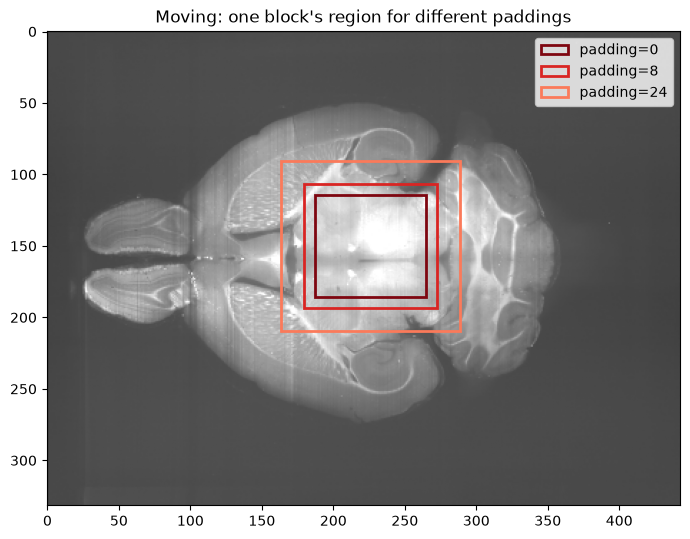

In [9]:
# 2. The same block with growing padding: wider interpolation kernels read
# further, so the region expands. Same color, lighter shades.
paddings = [0, 8, 24]
shades = plt.cm.Reds(np.linspace(0.95, 0.45, len(paddings)))

fig, ax = plt.subplots(figsize=[7, 5.5])
ax.imshow(moving_view_slice, cmap="gray", vmax=vmax_moving)
for pad, shade in zip(paddings, shades):
    padded = block_bounding_box(location, padding=pad)
    draw_box(ax, padded.start_index, padded.size, shade, label=f"padding={pad}")
ax.set_title("Moving: one block's region for different paddings")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

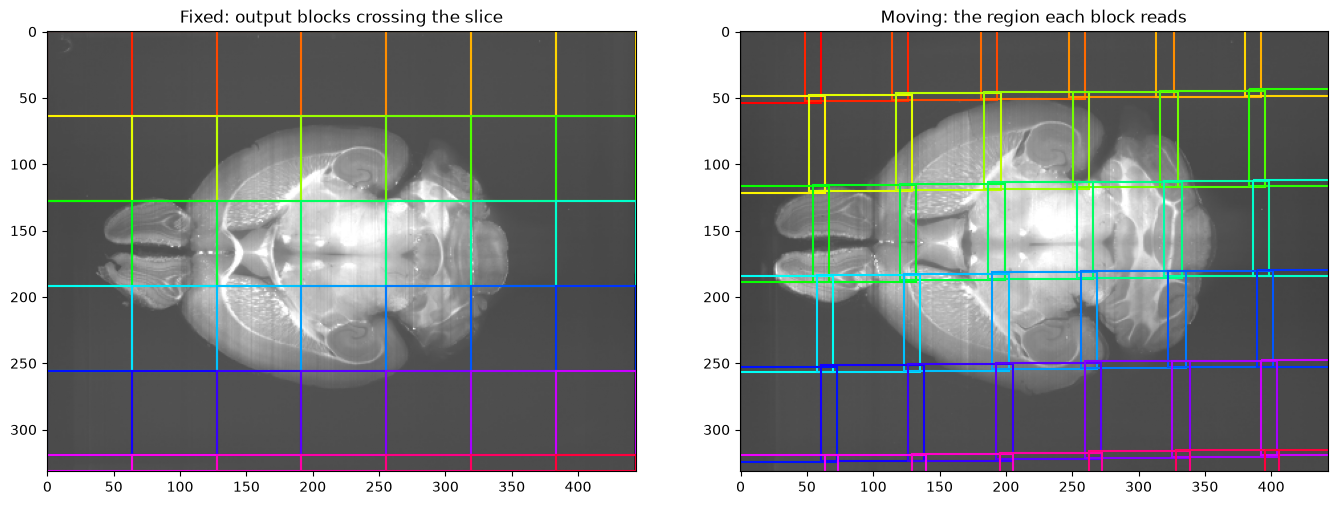

In [10]:
# 3. Every block of the slab and its moving-image region, one color per block.
# The regions overlap by the padding and follow the affine transform.
colors = plt.cm.hsv(np.linspace(0, 1, len(slab), endpoint=False))

fig, axs = plt.subplots(1, 2, figsize=[14, 5])
axs[0].imshow(fixed_view_slice, cmap="gray", vmax=vmax_fixed)
axs[1].imshow(moving_view_slice, cmap="gray", vmax=vmax_moving)
for block, color in zip(slab, colors):
    draw_box(
        axs[0],
        {"y": block[1][0], "x": block[2][0]},
        {"y": block[1][1] - block[1][0], "x": block[2][1] - block[2][0]},
        color,
        linewidth=1.5,
    )
    block_region = block_bounding_box(block)
    draw_box(axs[1], block_region.start_index, block_region.size, color, linewidth=1.5)
axs[0].set_title("Fixed: output blocks crossing the slice")
axs[1].set_title("Moving: the region each block reads")
plt.tight_layout()
plt.show()

## Benchmark

Two knobs decide what a resample costs, and neither is an argument of
`resample`: the size of an output block is the chunking of the
fixed image, and the number of blocks in flight is Dask's `num_workers`.
`benchmark` takes both, and reports the graph build, the wall clock of the
write, the throughput, and the peak resident memory of the process while it
ran.

Run against S3 the numbers below are the link, not the knobs: the resample
waits on the download either way, and the tradeoff only shows itself on stores
that are local. `BENCHMARK_LEVELS` defaults to the two coarse levels so the
cell stays quick;
extend it to `[3, 2, 1, 0]` to reproduce the tables below. Peak RSS inside one
kernel only ever grows, because the allocator keeps what it has taken, so the
published numbers come from a fresh process per point and are medians of three
runs.

In [11]:
class PeakMemory:
    "Peak resident set size of this process while the block runs, sampled every 50 ms."

    def __enter__(self):
        self.process = psutil.Process()
        self.peak = self.process.memory_info().rss
        self._stop = False

        def sample():
            while not self._stop:
                self.peak = max(self.peak, self.process.memory_info().rss)
                time.sleep(0.05)

        self._thread = threading.Thread(target=sample, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, *exc):
        self._stop = True
        self._thread.join()


def release_workers():
    """Shut down the thread pools Dask has cached, one per ``num_workers`` value.

    Each worker thread that resamples holds an itkwasm instance of its own, and
    Dask keeps a pool per distinct ``num_workers``, so sweeping the knob below
    in one process would pile instance upon instance rather than replace them.
    """
    for by_workers in list(threaded.pools.values()):
        for pool in list(by_workers.values()):
            pool.shutdown(wait=True)
        by_workers.clear()


def benchmark(level, block=None, workers=8):
    """One resample, from an empty graph to a written store.

    ``block`` rechunks the fixed image, which is what sets the output block
    size; ``workers`` is how many of those blocks Dask keeps in flight.
    """
    fixed = fixed_levels[level]
    if block is not None:
        fixed = replace(fixed, data=fixed.data.rechunk((block,) * fixed.data.ndim))

    start = time.perf_counter()
    image = resample(brain_transform, fixed, moving_levels[level])
    build = time.perf_counter() - start

    store = f"benchmark_level{level}.ome.zarr"
    with dask.config.set(num_workers=workers), PeakMemory() as memory:
        start = time.perf_counter()
        to_ome_zarr(store, to_multiscales(image, scale_factors=[]), overwrite=True)
        elapsed = time.perf_counter() - start
    release_workers()

    return {
        "level": level,
        "block": block or max(fixed.data.chunksize),
        "in flight": workers,
        "voxels (M)": round(image.data.size / 1e6, 1),
        "blocks": image.data.npartitions,
        "build (s)": round(build, 2),
        "seconds": round(elapsed, 1),
        "Mvoxel/s": round(image.data.size / elapsed / 1e6, 1),
        "peak RSS (GB)": round(memory.peak / 1e9, 2),
    }


def show(rows):
    "Print rows of the same shape as an aligned table."
    columns = list(rows[0])
    widths = [max(len(c), *(len(str(row[c])) for row in rows)) for c in columns]
    print("  ".join(c.rjust(w) for c, w in zip(columns, widths)))
    for row in rows:
        print("  ".join(str(row[c]).rjust(w) for c, w in zip(columns, widths)))


BENCHMARK_LEVELS = [3, 2]

show([benchmark(level) for level in BENCHMARK_LEVELS])

level  block  in flight  voxels (M)  blocks  build (s)  seconds  Mvoxel/s  peak RSS (GB)
    3    222          8         2.4       1        0.0     15.4       0.2           1.57
    2    256          8        18.9       4       0.01     24.1       0.8           1.73


In [12]:
# The two knobs against each other, at the finest level benchmarked. Smaller
# blocks hold less at once and pay more graph; larger ones amortize the graph
# and hold more. More blocks in flight buys throughput until the cores run out,
# and costs memory linearly all the way.
TRADEOFF_LEVEL = min(BENCHMARK_LEVELS)
TRADEOFF = [(128, 8), (128, 16), (192, 16), (192, 24), (256, 8), (256, 16)]

show(
    [
        benchmark(TRADEOFF_LEVEL, block=block, workers=workers)
        for block, workers in TRADEOFF
    ]
)

level  block  in flight  voxels (M)  blocks  build (s)  seconds  Mvoxel/s  peak RSS (GB)
    2    128          8        18.9      12       0.02     21.8       0.9           1.74
    2    128         16        18.9      12       0.02     13.7       1.4           1.72
    2    192         16        18.9       6       0.01     14.3       1.3           1.86
    2    192         24        18.9       6       0.01     21.9       0.9           1.86
    2    256          8        18.9       4       0.01     15.3       1.2           1.85
    2    256         16        18.9       4       0.01     15.1       1.3           1.84


Measured on a 24-core laptop, one fresh process per point, medians of three
runs, the stores read from a local copy of the same two prefixes (`aws s3 sync
--no-sign-request`).

**The output block size is the chunking that lands on disk.** It is
`fixed.data.chunks`, and `to_multiscales(scale_factors=[])` carries it through
to the store, so this is not an internal setting: choosing it chooses the shape
of the result. At level 0 (1213 million voxels, 2.4 GB in and 2.4 GB out):

| output block | in flight | Mvoxel/s | peak RSS |
|:---|---:|---:|---:|
| 128³ | 8 | 190 | 3.4 GB |
| 128³ | 16 | 230 | 4.0 GB |
| 192³ | 16 | 255 | 4.5 GB |
| 192³ | 24 | 270 | 4.9 GB |
| 256³ | 8 | 175 | 4.2 GB |
| 256³ | 16 | 210 | 5.3 GB |

The row to avoid is the one that comes for free: inheriting these stores' own
256³ gives fewer blocks than the machine has cores and a larger region to read
for each, so at 16 in flight it is 9% slower than 128³ for 24% more memory.
128³ is what ngff-zarr picks for a 3D pyramid anyway, so the conventional
choice is also the good one here. 192³ buys another 10% and writes a chunking
no viewer expects.

**Memory is the blocks in flight, plus a constant.** Sweeping from 1 to 24 fits
`peak = 2.7 GB + 62 MB per block in flight` at 128³ and `2.8 GB + 100 MB` at
192³, each to within 0.1 GB. The two slopes decompose into about 45 MB of
itkwasm instance per worker thread, which the block size does not change, plus
roughly four times the block's own bytes: the crop read in, its copy inside the
wasm heap, the resampled block coming out. The constant is the loaded modules
plus the moving chunks a block shares with its neighbours, held while the front
of the sweep passes, so it grows with the image's cross-section rather than its
volume (0.30 GB at level 1 against 1.66 GB at level 0, for eight times the
data). Nothing holds the output: it is written block by block.

**Level by level**, at 128³ with 16 in flight, from local disk:

| level | shape (z, y, x) | voxels | blocks | graph | write | peak RSS |
|---:|:---|---:|---:|---:|---:|---:|
| 3 | 64 × 166 × 222 | 2.4 M | 4 | 0.05 s | 0.15 s | 1.1 GB |
| 2 | 128 × 332 × 444 | 19 M | 12 | 0.02 s | 0.26 s | 1.5 GB |
| 1 | 256 × 665 × 888 | 151 M | 84 | 0.10 s | 0.73 s | 1.8 GB |
| 0 | 513 × 1331 × 1776 | 1213 M | 770 | 0.83 s | 5.14 s | 4.0 GB |

**Streamed from S3**, at 192³ with 16 in flight, over a link in Europe that
sustained about 1.5 MB/s, where the wall clock is the download and nothing else:

| level | blocks | wall | peak RSS | moving chunks named / in the level |
|---:|---:|---:|---:|:---|
| 3 | 2 | 5.6 s | 1.2 GB | 1 / 1 |
| 2 | 6 | 18.2 s | 1.4 GB | 4 / 4 |
| 1 | 40 | 105.4 s | 2.1 GB | 12 / 12 |
| 0 | 210 | 985.6 s | 3.7 GB | 126 / 126 |

The last column checks the central claim without reading a byte: the graph
names exactly one task per moving chunk at every level, so a chunk several
blocks need crosses the network once. What is then paid over S3 is the moving
level itself, 1.5 GB compressed at level 0, and the same code runs at disk
speed next to the bucket.

**Where the time goes.** Computing every block and dropping it, with no store
to write, runs at 366 Mvoxel/s against 271 end to end, so the write is about a
quarter of the wall clock and the resample the rest. Building the graph costs
one bounding box per block and is paid once: 0.2 s for the 126 blocks of 256³,
0.2 s for the 210 of 192³, 0.8 s for the 770 of 128³, and 5.7 s for the 5292 of
64³, which is where a finer decomposition stops paying for itself.
